# 01 · Nodes

**What this teaches:** what a node is, what it receives, what it returns, and how to
put one in a graph and run it.

We build a calculator: one node per operation.

## LangGraph

LangGraph is a low-level orchestration framework and runtime for building, managing,
and deploying long-running, stateful agents.

| Piece | What it is | Notebook |
| --- | --- | --- |
| **Node** | A single step in the graph | 01 ← you are here |
| **State** | The data every node reads and writes | 02 |
| **Edges** | Control flow between nodes — serial, parallel, conditional | 03 |
| **Checkpointers** | Save and restore graph state over time | 04 |
| **Interrupts** | Pause execution and wait for a human | 05 |
| **Tools** | Callable functions with typed inputs and outputs | 06 |
| **Models** | The chat models that drive the agentic steps | 07 |

<img src="./assets/States_Nodes.png" align="left" width="600" style="margin-right:15px;"/>

## What is a node?

From the [Graph API docs](https://docs.langchain.com/oss/python/langgraph/graph-api#nodes):

> **Nodes** are "functions that encode the logic of your agents. They receive the
> current state as input, perform some computation or side-effect, and return an
> updated state."

A node is a plain Python function:

- it takes the current **state** as its first positional argument
- it returns a **dict of the state keys it wants to change**

In [1]:
import operator
from typing import Annotated

from IPython.display import Image, display
from langgraph.graph import END, START, StateGraph
from typing_extensions import TypedDict

`StateGraph` needs a schema before it will let us add a node. Two operands and a
result is all a calculator needs to start. State gets its own notebook in
[02-state.ipynb](./02-state.ipynb).

In [2]:
class State(TypedDict):
    a: float
    b: float
    result: float

## Writing a node

`add` reads the two operands and returns the one key it changes.

In [3]:
def add(state: State) -> dict:
    print(f"---add--- {state['a']} + {state['b']}")
    return {"result": state["a"] + state["b"]}

## Putting the node in a graph

1. `StateGraph(State)` — start a builder bound to a state schema
2. `add_node(...)` / `add_edge(...)` — describe the graph
3. `compile()` — turn the description into something runnable

[START](https://docs.langchain.com/oss/python/langgraph/graph-api#start-node) "represents
the node that sends user input to the graph" and
[END](https://docs.langchain.com/oss/python/langgraph/graph-api#end-node) "represents a
terminal node". Edges get their own notebook.

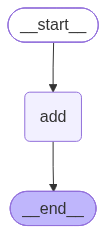

In [4]:
builder = StateGraph(State)
builder.add_node("add", add)

builder.add_edge(START, "add")
builder.add_edge("add", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

## Running it

In [5]:
graph.invoke({"a": 3, "b": 4})

---add--- 3 + 4


{'a': 3, 'b': 4, 'result': 7}

`a` and `b` came back untouched and `result` appeared. A node only changes the keys it
returns; by default a returned key **overwrites** the old value.

## Nodes return partial updates

`divide` below returns one key out of four. The operands and the label pass through
without the node mentioning them.

In [6]:
class WideState(TypedDict):
    a: float
    b: float
    result: float
    label: str


def divide(state: WideState) -> dict:
    return {"result": state["a"] / state["b"]}


wide = StateGraph(WideState)
wide.add_node("divide", divide)
wide.add_edge(START, "divide")
wide.add_edge("divide", END)

wide.compile().invoke({"a": 9, "b": 2, "label": "nine halved"})

{'a': 9, 'b': 2, 'result': 4.5, 'label': 'nine halved'}

## Naming nodes

`add_node` takes an optional name. Leave it out and the node is named after the
function.

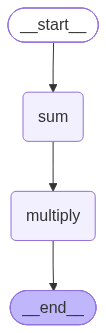

In [7]:
def multiply(state: State) -> dict:
    return {"result": state["a"] * state["b"]}


named = StateGraph(State)
named.add_node("sum", add)       # explicit name: "sum"
named.add_node(multiply)         # inferred name: "multiply"

named.add_edge(START, "sum")
named.add_edge("sum", "multiply")
named.add_edge("multiply", END)

display(Image(named.compile().get_graph().draw_mermaid_png()))

Names matter because every edge refers to a node by name. Note that `multiply` ran
second and overwrote `result` — both nodes write the same key.

## Several nodes in a row

A calculator chain: each node applies one operation to a running `value` and records
what it did. The prints make the order visible.

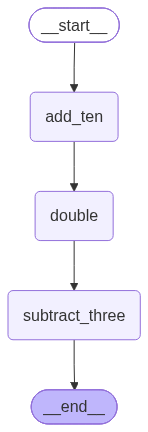

In [8]:
class Pipeline(TypedDict):
    value: float
    steps: Annotated[list[str], operator.add]


def add_ten(state: Pipeline) -> dict:
    new = state["value"] + 10
    print(f"---add_ten--- {state['value']} + 10 = {new}")
    return {"value": new, "steps": ["+10"]}


def double(state: Pipeline) -> dict:
    new = state["value"] * 2
    print(f"---double--- {state['value']} x 2 = {new}")
    return {"value": new, "steps": ["x2"]}


def subtract_three(state: Pipeline) -> dict:
    new = state["value"] - 3
    print(f"---subtract_three--- {state['value']} - 3 = {new}")
    return {"value": new, "steps": ["-3"]}


pipe = StateGraph(Pipeline)
pipe.add_node(add_ten)
pipe.add_node(double)
pipe.add_node(subtract_three)

pipe.add_edge(START, "add_ten")
pipe.add_edge("add_ten", "double")
pipe.add_edge("double", "subtract_three")
pipe.add_edge("subtract_three", END)

pipe_graph = pipe.compile()
display(Image(pipe_graph.get_graph().draw_mermaid_png()))

In [9]:
pipe_graph.invoke({"value": 5, "steps": []})

---add_ten--- 5 + 10 = 15
---double--- 15 x 2 = 30
---subtract_three--- 30 - 3 = 27


{'value': 27, 'steps': ['+10', 'x2', '-3']}

`value` was overwritten at each step, but `steps` collected every operation instead of
replacing it. That difference is the `Annotated[list[str], operator.add]` reducer —
the subject of [02-state.ipynb](./02-state.ipynb).

## Node summary

| | |
| --- | --- |
| **Receives** | the current state as its first positional argument |
| **Returns** | a `dict` of the state keys it wants to change, or `None` to change nothing |
| **May** | do any Python work call an API, read a file, print, run a model |
| **Must not** | mutate the state object in place; return a value for a key not in the schema |